In [1]:
# Carga de librerías
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Detección de rutas relativas al notebook actual
BASE_DIR = Path().resolve()
PROJECT_DIR = BASE_DIR.parent
DATA_RAW = PROJECT_DIR / 'data' / 'raw'
# Crear carpeta en caso de que no exista
DATA_RAW.mkdir(parents=True,exist_ok=True)
print('Project directory:',PROJECT_DIR)
print('Raw data path:',DATA_RAW)

Project directory: C:\Users\adnac\OneDrive\Documentos\Data_Science_Projects\Proyectos\Financial_Risk_Project
Raw data path: C:\Users\adnac\OneDrive\Documentos\Data_Science_Projects\Proyectos\Financial_Risk_Project\data\raw


In [3]:
# Obtención de datos de yahoo finance
START_DATE = '2010-01-01'
END_DATE = '2024-12-31'
TICKER = '^GSPC'
data = yf.download(TICKER,start=START_DATE,end=END_DATE)

[*********************100%***********************]  1 of 1 completed


In [4]:
# Información básica
display(data.head(5))
print(data.info())

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2010-01-04,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1145.390015,1136.219971,1140.520020,4389590000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3773 entries, 2010-01-04 to 2024-12-30
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^GSPC)   3773 non-null   float64
 1   (High, ^GSPC)    3773 non-null   float64
 2   (Low, ^GSPC)     3773 non-null   float64
 3   (Open, ^GSPC)    3773 non-null   float64
 4   (Volume, ^GSPC)  3773 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 176.9 KB
None


In [5]:
# Información de calidad general de los datos
# Valores faltantes
print('Missing values:\n',data.isna().sum())
# Valores duplicados
print('Duplicated values:\n',data.index.duplicated().sum())
# Orden temporal
data = data.sort_index()

Missing values:
 Price   Ticker
Close   ^GSPC     0
High    ^GSPC     0
Low     ^GSPC     0
Open    ^GSPC     0
Volume  ^GSPC     0
dtype: int64
Duplicated values:
 0


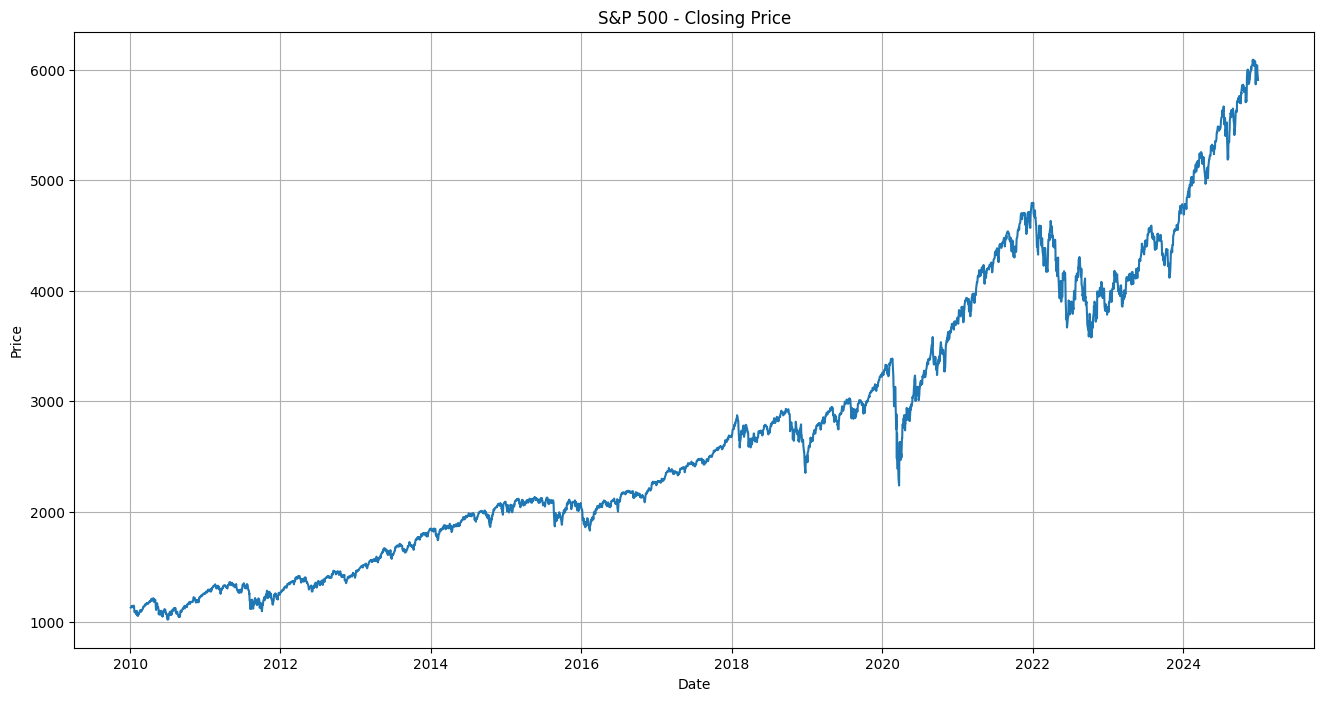

In [6]:
# Visualización básica de la información extraída
plt.figure(figsize=(16,8))
plt.plot(data['Close'])
plt.title('S&P 500 - Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid()
plt.show()

In [7]:
data.index.name = 'Date'
file_path = DATA_RAW / 'sp500.csv'
data.to_csv(file_path)
print(f'File saved in:{file_path}')

File saved in:C:\Users\adnac\OneDrive\Documentos\Data_Science_Projects\Proyectos\Financial_Risk_Project\data\raw\sp500.csv
